# SEGMENTACIÓN DE LA CARTERA

Este notebook trata de encontrar perfiles de riesgo diferenciados en la cartera, para ello utilizamos el algoritmo de segmentación K-means. Gracias a estos grupos de riesgo conseguiremos:
- **Homogeneidad en el riesgo**. Distintos perfiles de riesgo cuyos integrantes compartan un riesgo similar.
- **Explicabilidad**. De cara al futuro uso de una red neuronal Bayesiana para predecir el `Total Claim Amount`, los distintos clusteres actuarán como prior sobre la distribución del riesgo.

##### Setup del Notebook 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibilidad ──
SEED = 42
np.random.seed(SEED)

# ── Paths ──
DATA_PATH  = '../data/processed/fase2/'
OUTPUT_DIR = '../data/processed/fase3/'   # donde se guardan los artefactos para las fases siguientes

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

##### Carga e Inspección del conjunto de Datos

In [3]:
df = pd.read_csv(DATA_PATH + "X_famd_completo.csv")
print(f"Dataset cargado: {df.shape[0]:,} registros × {df.shape[1]} variables")
columnas = df.columns.to_list()
print(f"Las columnas del conjunto de datos son:\n{columnas}")

Dataset cargado: 8,971 registros × 6 variables
Las columnas del conjunto de datos son:
['Customer', 'FC1', 'FC2', 'FC3', 'FC4', 'FC5']


### 1. Validación de las variables usadas para segmentar
El algoritmo _K-means_ se basa en distancias euclideas entre variables, por lo que es muy sensible a valores atípicos que sean mucho mayores al resto de valores que toma la variable, estos outliers desplazarían artificalmente los centros de los grupos provocando asignaciones inestables y arruinando la homogeneidad.. Nosotros usaremos como variables discriminantes los factores obtenidos en la fase anterior, comprobaremos que son adecuados para segmentar.

El diagnóstico de outliers usará:
- Boxplots. Inspección rápiday visual.
- Z-Scores y Rango Intercuartílico (IQR). Contabilizar que porcentaje de la cartera tiene comportamientos anómalos.

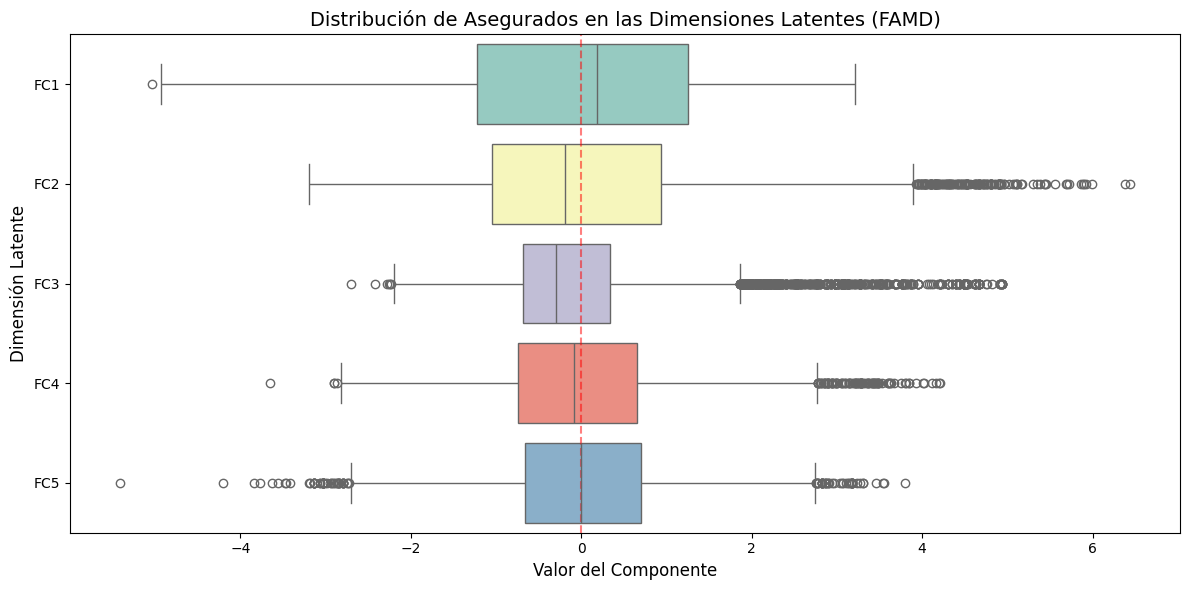

In [5]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, palette="Set3", orient='h')
plt.title('Distribución de Asegurados en las Dimensiones Latentes (FAMD)', fontsize=14)
plt.xlabel('Valor del Componente', fontsize=12)
plt.ylabel('Dimensión Latente', fontsize=12)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [20]:
df['FC1']

0       1.423939
1      -2.203859
2       0.056900
3      -1.896872
4       1.182344
          ...   
8966   -0.467167
8967    1.861633
8968   -2.137114
8969   -0.123350
8970   -1.934061
Name: FC1, Length: 8971, dtype: float64

In [21]:
print("--- REPORTE DE OUTLIERS EXTREMOS (Z-Score > 3) ---")
columnas = ['FC1', 'FC2', 'FC3', 'FC4', 'FC5']
for col in columnas:
    z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
    # Contamos cuántos asegurados exceden las 3 desviaciones estándar
    num_outliers = (z_scores > 3).sum()
    pct_outliers = (num_outliers / len(df)) * 100
    print(f"{col}: {num_outliers} asegurados ({pct_outliers:.2f}%) con comportamiento extremo.")

--- REPORTE DE OUTLIERS EXTREMOS (Z-Score > 3) ---
FC1: 6 asegurados (0.07%) con comportamiento extremo.
FC2: 72 asegurados (0.80%) con comportamiento extremo.
FC3: 174 asegurados (1.94%) con comportamiento extremo.
FC4: 57 asegurados (0.64%) con comportamiento extremo.
FC5: 35 asegurados (0.39%) con comportamiento extremo.


El porcentaje de asegurados con comportamientos anómalos está por debajo del 2% en cada factor, lo cual nos parece un comportamiento admisible. También veremos si hay alguna perona que resulte atípica en varios factores a la vez.

In [22]:
z_scores_df = np.abs((df[columnas] - df[columnas].mean()) / df[columnas].std())
outliers_mask = (z_scores_df > 3)
severos = (outliers_mask.sum(axis=1) >= 2).sum()

print("\n--- CONCLUSIÓN MULTIVARIANTE ---")
print(f"Asegurados atípicos en 2 o más dimensiones: {severos} ({(severos / len(df)) * 100:.2f}%)")


--- CONCLUSIÓN MULTIVARIANTE ---
Asegurados atípicos en 2 o más dimensiones: 6 (0.07%)


De nuevo, no es un número preocupante. Nuesras variables parecen válidas para segmentar usando _K-means_

### 2. Determinar Nº de Clusters

Debemos encontrar un número de perfiles de riesgo que suponga un trade off adecuado entre la matemática y el sentido actuarial. Debe responder ante las intuiciones de negocio sin perder de vista la matemática detrs del algoritmo. Para ello nos apoyamos entres pilares:
- El _Coeficiente de Silhouette_. Esta métrica evalúa la calidad del agrupamiento en base a la cohesión entre los asegurados de cada grupo y la separeación entre los asegurados de grupos distintos.
- El Método del Codo. Es menos robusto que _Shilouette_ pero más visual, toma en cuenta la varianza y busca el punto de inflexión en el que seguir añadiendo grupos no consigue que se reduzca la varianza.
- Criterio Actuarial enfocado en el negocio. Debemos obtener un número de grupos suficiente para representar al total de la cartera de una forma equilibrada.

### 3. Segmentación

### 4. Métricas de Segmentación

### 5. Interpretación y Validación de los Segmentos

Usar variables estratificación y `Total Claim Amount`